In [1]:
#---IMPORTS---
import torch
from torch import nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt


In [2]:
#---CONFIGS---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
EPOCHS = 30
BATCH_SIZE = 128
IMG_CHANNEL = 1
FEATURE_D = 64
FEATURE_G = 64
Z_CHANNEL = 100
LEARNING_RATE = 2e-4

cuda


In [3]:
#---DATASET---
transform = transforms.Compose(
    [transforms.Resize(size= (64, 64)),
     transforms.ToTensor(),
     transforms.Normalize([0.5 for _ in range(IMG_CHANNEL)],[0.5 for _ in range(IMG_CHANNEL)])]
)

dataset = datasets.MNIST(root= "data",
                         train= True,
                         transform= transform,
                         download= True)

loader = DataLoader(dataset= dataset,
                    batch_size= BATCH_SIZE,
                    shuffle= True,
                    )

In [4]:
print(f"Size of dataset: {len(dataset)}")
print(f"Total Batches: {len(loader)}")
batch0 = next(iter(loader))
print(f"Shape of a batch: {batch0[0].shape}")

Size of dataset: 60000
Total Batches: 469
Shape of a batch: torch.Size([128, 1, 64, 64])


In [5]:
#---MODELS---
class Discriminator(nn.Module):
    def __init__(self, IMG_CHANNEL, FEATURE_D ):
        super().__init__()

        self.disc = nn.Sequential(
            nn.Conv2d(IMG_CHANNEL, FEATURE_D, kernel_size= 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),

            self._block(FEATURE_D, FEATURE_D*2, 4, 2, 1),
            self._block(FEATURE_D*2, FEATURE_D*4, 4, 2, 1),
            self._block(FEATURE_D*4, FEATURE_D*8, 4, 2, 1),

            nn.Conv2d(FEATURE_D*8, 1, 4, 2, 0),
            nn.Sigmoid()
            )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels,
                      out_channels,
                      kernel_size,
                      stride,
                      padding,
                      bias= False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
            )

    def forward(self, x):
        return self.disc(x)


class Generator(nn.Module):
    def __init__(self, Z_CHANNEL, IMG_CHANNEL, FEATURE_G):
        super().__init__()

        self.gen = nn.Sequential(
            self._block(Z_CHANNEL, FEATURE_G*16, 4, 1, 0),
            self._block(FEATURE_G*16, FEATURE_G*8, 4, 2, 1),
            self._block(FEATURE_G*8, FEATURE_G*4, 4, 2, 1),
            self._block(FEATURE_G*4, FEATURE_G*2, 4, 2, 1),

            nn.ConvTranspose2d(FEATURE_G*2, IMG_CHANNEL, 4, 2, 1),
            nn.Tanh()
            )
    
    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels,
                      out_channels,
                      kernel_size,
                      stride,
                      padding,
                      bias= False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
            )

    def forward(self, x):
        return self.gen(x)
    

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)


def test():
    N, img_channels, H, W = 8, 3, 64, 64
    noise_dim = 100
    x = torch.randn((N, img_channels, H, W))
    disc = Discriminator(img_channels, 8)
    assert disc(x).shape == (N, 1, 1, 1), "Discriminator test failed"
    gen = Generator(noise_dim, img_channels, 8)
    z = torch.randn((N, noise_dim, 1, 1))
    assert gen(z).shape == (N, img_channels, H, W), "Generator test failed"
    print("Success, tests passed!")

test()

Success, tests passed!


In [6]:
#---TRAINING_SETUP---
disc = Discriminator(IMG_CHANNEL, FEATURE_D).to(device)
gen = Generator(Z_CHANNEL, IMG_CHANNEL, FEATURE_G).to(device)

initialize_weights(disc)
initialize_weights(gen)

optim_d = optim.Adam(disc.parameters(), lr = LEARNING_RATE, betas=(0.5, 0.999))
optim_g = optim.Adam(gen.parameters(), lr = LEARNING_RATE, betas=(0.5, 0.999))
criterion = nn.BCELoss()

fixed_noise = torch.randn(BATCH_SIZE, Z_CHANNEL, 1, 1).to(device)

writer_fake = SummaryWriter(log_dir= "logs/fake")
writer_real = SummaryWriter(log_dir= "logs/real")

step = 0

In [7]:
#---TRAINING_LOOP---
for epoch in range(EPOCHS):
    for batch, (real, _) in enumerate(loader):
        real = real.to(device)
        noise = torch.randn(real.shape[0], Z_CHANNEL, 1, 1).to(device)
        fake = gen(noise)

        real_D = disc(real).reshape(-1)
        
        lossD_real = criterion(real_D, torch.ones_like(real_D))
        fake_D = disc(fake.detach()).reshape(-1)
        lossD_fake = criterion(fake_D, torch.zeros_like(fake_D))

        lossD = (lossD_fake + lossD_real) / 2

        optim_d.zero_grad()
        
        lossD.backward()

        optim_d.step()


        output = disc(fake).reshape(-1)

        lossG = criterion(output, torch.ones_like(output))

        optim_g.zero_grad()

        lossG.backward()

        optim_g.step()


        if batch % 100 == 0:
            print(f"Epoch [{epoch}/{EPOCHS}] Batch {batch}/{len(loader)} \
                  Loss D: {lossD:.4f}, loss G: {lossG:.4f}")
        
            with torch.no_grad():
                fake = gen(fixed_noise)

                img_grid_real = torchvision.utils.make_grid(real[:32], normalize=True)
                img_grid_fake = torchvision.utils.make_grid(fake[:32], normalize=True)

                writer_real.add_image("Real", img_grid_real, global_step=step)
                writer_fake.add_image("Fake", img_grid_fake, global_step=step)

                step += 1

        

Epoch [0/30] Batch 0/469                   Loss D: 0.6980, loss G: 0.7337
Epoch [0/30] Batch 100/469                   Loss D: 0.0159, loss G: 4.0938
Epoch [0/30] Batch 200/469                   Loss D: 0.0766, loss G: 3.9642
Epoch [0/30] Batch 300/469                   Loss D: 0.1431, loss G: 2.1944
Epoch [0/30] Batch 400/469                   Loss D: 0.0771, loss G: 2.9731
Epoch [1/30] Batch 0/469                   Loss D: 0.1298, loss G: 2.7221
Epoch [1/30] Batch 100/469                   Loss D: 0.5681, loss G: 0.8873
Epoch [1/30] Batch 200/469                   Loss D: 0.5074, loss G: 1.0532
Epoch [1/30] Batch 300/469                   Loss D: 0.3558, loss G: 1.0209
Epoch [1/30] Batch 400/469                   Loss D: 0.4100, loss G: 2.3752
Epoch [2/30] Batch 0/469                   Loss D: 0.4594, loss G: 1.7237
Epoch [2/30] Batch 100/469                   Loss D: 0.9802, loss G: 1.4237
Epoch [2/30] Batch 200/469                   Loss D: 0.3999, loss G: 2.2026
Epoch [2/30] Batch

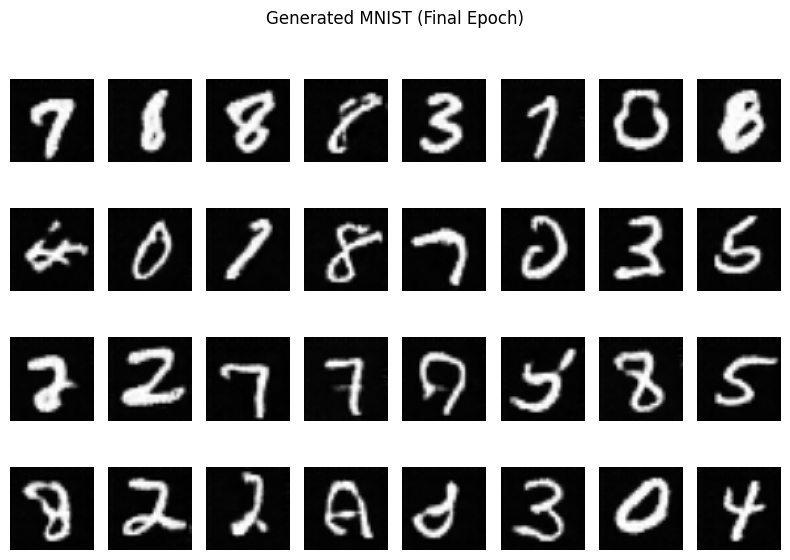

In [9]:
#---VISUALIZATION---
with torch.no_grad():
    sample = gen(fixed_noise).reshape(-1, 1, 64, 64).cpu()
    sample = sample * 0.5 + 0.5

    fig, axes = plt.subplots(4,8, figsize=(8, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(sample[i].permute(1, 2, 0).clamp(0, 1), cmap= 'gray')
        ax.axis("off")
    plt.suptitle("Generated MNIST (Final Epoch)")
    plt.tight_layout()
    plt.show()